## Wardrobe Genie

WHAT IT IS :
Ai based outfit recommendation using deep learning and style embeddings




People often struggle to decide what to wear despite having many clothes.
we aim to build an AI system that automatically analyzes a user’s wardrobe and suggests stylish outfit combinations

We aim to:
1. Detect and classify clothes (shirt, jeans, dress, shoes etc)
2. Learn style similarity between clothes
3. Generate outfit combinations automatically

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kushagrajain0710","key":"c53116e7a14193da6d09273a669133e7"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install kaggle

using https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-dataset?resource=download&SSORegistrationToken=CfDJ8L9-_gcGHthJtufiBgcc1oaXGjgFRgyJHvynSEF2Gn38JzhnHxJ0V0m_HJiPuDmJiwmaU5wKVF89GjsnjMcNp4DmEOBKjbeLVoFb4vZzHzB7P2YCqTCB9IYFsFUvxlZ41tKVwNh-AAAtjzF0bGuCKO2vwdyDsC7WmjvsqaNgLtom2vZ1B6C-hArG3d5cVJh74UJmxfSlq8Jm4vGKEkVzcvL0JxMZS99U6rT1A41tr_G1zWisKzE_wgW1SsmbKzHUbR-1AgY4zMmLFflqT7PWzH25TsIGqhjslxN1tTdLrxmoEjrUp6IdvgVhL1w7G1FfuPkw4ONzHjqpNd1YwpE7dtvYnftu3mkzgCGq6UoS6Yk&DisplayName=rajnandini%20singh as dataset for our model

In [ ]:
!kaggle datasets download -d paramaggarwal/fashion-product-images-small
!unzip fashion-product-images-small.zip

Streaming output truncated to the last 5000 lines.
  inflating: myntradataset/images/5813.jpg  
  inflating: myntradataset/images/58131.jpg  
  inflating: myntradataset/images/58132.jpg  
  inflating: myntradataset/images/58133.jpg  
  inflating: myntradataset/images/58135.jpg  
  inflating: myntradataset/images/58136.jpg  
  inflating: myntradataset/images/58137.jpg  
  inflating: myntradataset/images/58138.jpg  
  inflating: myntradataset/images/58139.jpg  
  inflating: myntradataset/images/5814.jpg  
  inflating: myntradataset/images/58140.jpg  
  inflating: myntradataset/images/58141.jpg  
  inflating: myntradataset/images/58143.jpg  
  inflating: myntradataset/images/58144.jpg  
  inflating: myntradataset/images/58145.jpg  
  inflating: myntradataset/images/58146.jpg  
  inflating: myntradataset/images/58147.jpg  
  inflating: myntradataset/images/58148.jpg  
  inflating: myntradataset/images/58149.jpg  
  inflating: myntradataset/images/5815.jpg  
  inflating: myntradataset/image

In [ ]:
#imports
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [ ]:
#loading csv
df = pd.read_csv('/content/styles.csv', on_bad_lines='skip', low_memory=False)
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:
#selecting important columns
df = df[['id', 'articleType']]
df.dropna(inplace=True)

print("Total rows:", len(df))
df.head()

Total rows: 44424


,id,articleType
0,15970,Shirts
1,39386,Jeans
2,59263,Watches
3,21379,Track Pants
4,53759,Tshirts


In [ ]:
#load csv
df = pd.read_csv('/content/styles.csv', on_bad_lines='skip')
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:
!ls

fashion-product-images-small.zip  kaggle.json	 sample_data
images				  myntradataset  styles.csv


In [ ]:
print("After sampling:", len(df))

After sampling: 5000


In [ ]:
df = df[['id', 'articleType']]
df.dropna(inplace=True)

In [ ]:
#creating image path to link ids in csv to link with image path
image_folder = '/content/images/'

df['image_path'] = df['id'].astype(str) + '.jpg'
df['image_path'] = df['image_path'].apply(lambda x: os.path.join(image_folder, x))

df.head()

,id,articleType,image_path
0,23870,Track Pants,/content/images/23870.jpg
1,17395,Socks,/content/images/17395.jpg
2,6404,Sandals,/content/images/6404.jpg
3,27550,Shirts,/content/images/27550.jpg
4,28852,Tshirts,/content/images/28852.jpg


In [ ]:
#removing missing images
df = df[df['image_path'].apply(os.path.exists)]
df.reset_index(drop=True, inplace=True)

print("Valid images:", len(df))

Valid images: 5000


In [ ]:
#reducing dataset
df = df.sample(5000)
df.reset_index(drop=True, inplace=True)

labels = df['articleType'].unique()
label_map = {label: idx for idx, label in enumerate(labels)}

df['label'] = df['articleType'].map(label_map)

print("Number of classes:", len(label_map))

Number of classes: 112


In [ ]:
#enocding labels
labels = df['articleType'].unique()
label_map = {label: idx for idx, label in enumerate(labels)}

df['label'] = df['articleType'].map(label_map)

print(label_map)

{'Tunics': 0, 'Track Pants': 1, 'Handbags': 2, 'Tops': 3, 'Shirts': 4, 'Watches': 5, 'Heels': 6, 'Flats': 7, 'Tshirts': 8, 'Clutches': 9, 'Deodorant': 10, 'Sarees': 11, 'Sports Shoes': 12, 'Briefs': 13, 'Formal Shoes': 14, 'Bra': 15, 'Sandals': 16, 'Flip Flops': 17, 'Belts': 18, 'Caps': 19, 'Sweatshirts': 20, 'Sweaters': 21, 'Kurtis': 22, 'Earrings': 23, 'Socks': 24, 'Dresses': 25, 'Casual Shoes': 26, 'Shorts': 27, 'Laptop Bag': 28, 'Innerwear Vests': 29, 'Night suits': 30, 'Lip Gloss': 31, 'Kurtas': 32, 'Backpacks': 33, 'Sunglasses': 34, 'Bangle': 35, 'Kajal and Eyeliner': 36, 'Skirts': 37, 'Trousers': 38, 'Face Moisturisers': 39, 'Wallets': 40, 'Mufflers': 41, 'Scarves': 42, 'Jeans': 43, 'Lipstick': 44, 'Body Wash and Scrub': 45, 'Nail Polish': 46, 'Jackets': 47, 'Dupatta': 48, 'Pendant': 49, 'Ties': 50, 'Foundation and Primer': 51, 'Lounge Pants': 52, 'Salwar': 53, 'Cufflinks': 54, 'Lip Liner': 55, 'Camisoles': 56, 'Leggings': 57, 'Jewellery Set': 58, 'Lip Care': 59, 'Jeggings': 60,

In [ ]:
#loading images
IMG_SIZE = 128

def load_images(df):
    images = []
    labels = []

    for i in range(len(df)):
        try:
            img = cv2.imread(df['image_path'][i])
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(df['label'][i])
        except:
            continue

    return np.array(images), np.array(labels)

X, y = load_images(df)

print("Images shape:", X.shape)

Images shape: (5000, 128, 128, 3)


In [ ]:
X, y = load_images(df)

In [ ]:
#normalizing
X = X / 255.0

In [ ]:
#training testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
#one hot encoding to convert labels into binary vectors
from tensorflow.keras.utils import to_categorical

num_classes = len(label_map)

y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)


In [ ]:
#cnn model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'), #detects patterns like edges/ shapes
    MaxPooling2D(2,2), #reduces size keeping important features

    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(label_map), activation='softmax') #final decision, classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.3913 - loss: 2.7677 - val_accuracy: 0.5520 - val_loss: 1.9204
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6195 - loss: 1.4943 - val_accuracy: 0.6200 - val_loss: 1.4819
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7275 - loss: 1.0292 - val_accuracy: 0.6330 - val_loss: 1.4958
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7972 - loss: 0.7155 - val_accuracy: 0.6670 - val_loss: 1.4529
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8530 - loss: 0.4881 - val_accuracy: 0.6300 - val_loss: 1.6512


In [ ]:
model.predict(X[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step


array([[9.7705621e-01, 1.8747253e-06, 8.8612171e-07, 4.1177849e-05,
        6.8106228e-03, 8.9689723e-07, 4.1556036e-10, 3.1952233e-11,
        1.4252911e-04, 3.4595931e-08, 1.0744572e-10, 6.8809314e-08,
        1.2049478e-09, 1.7132910e-06, 1.5531503e-09, 5.1829431e-07,
        1.6114216e-08, 7.7410284e-08, 1.6382367e-09, 1.3981433e-08,
        4.8735514e-05, 2.0879166e-05, 1.2746361e-06, 5.4261324e-07,
        1.0099339e-08, 4.9605351e-03, 5.5729723e-09, 8.6934642e-07,
        9.6809435e-07, 8.5256424e-09, 3.0750871e-06, 3.6908675e-12,
        9.1376184e-03, 1.3318720e-07, 2.0020823e-07, 2.9741602e-07,
        2.5179733e-10, 1.2150159e-07, 1.1788866e-07, 1.4626146e-11,
        3.8849907e-10, 5.9250695e-13, 1.3118806e-06, 2.0286188e-07,
        2.8833002e-13, 4.7395630e-09, 4.9810769e-14, 1.0087607e-06,
        6.9608097e-05, 5.8955207e-10, 1.3015826e-07, 1.3397908e-09,
        1.8653308e-09, 5.6080185e-10, 7.7130959e-09, 3.8785307e-12,
        1.3621704e-08, 3.6532832e-09, 1.3044443e

In [ ]:
from tensorflow.keras.layers import Input

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(128,128,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(label_map), activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.3750 - loss: 3.0149 - val_accuracy: 0.5860 - val_loss: 1.7260
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6363 - loss: 1.4491 - val_accuracy: 0.6110 - val_loss: 1.5115
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7322 - loss: 0.9967 - val_accuracy: 0.6270 - val_loss: 1.5242
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8075 - loss: 0.6943 - val_accuracy: 0.6400 - val_loss: 1.4940
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8575 - loss: 0.4983 - val_accuracy: 0.6330 - val_loss: 1.5531


In [ ]:
#feature extraction
from tensorflow.keras.models import Model

feature_model = Model(
    inputs=model.layers[0].input,
    outputs=model.layers[-2].output
)

features = feature_model.predict(X)
print("Feature shape:", features.shape)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Feature shape: (5000, 128)


In [ ]:
#similarity function
from sklearn.metrics.pairwise import cosine_similarity

def find_similar(index, top_n=5):
    similarity = cosine_similarity([features[index]], features)[0]

    similar_indices = similarity.argsort()[-top_n-1:-1][::-1]

    return similar_indices

In [ ]:
#show similar outfits
def show_recommendations(index):
    plt.figure(figsize=(10,4))

    # original image
    plt.subplot(1,6,1)
    plt.imshow(X[index])
    plt.title("Input")
    plt.axis('off')

    # similar images
    similar = find_similar(index)

    for i, idx in enumerate(similar):
        plt.subplot(1,6,i+2)
        plt.imshow(X[idx])
        plt.axis('off')

    plt.show()

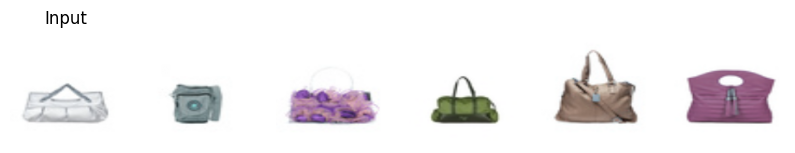

In [ ]:
#testing
show_recommendations(10)

In [ ]:
#ADDING AUTOENCODER

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_dim = features.shape[1]

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
#training autoencoder
autoencoder.fit(features, features, epochs=10, batch_size=32)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 14.1565
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.0843
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.0764
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.0708
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.0637
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.0605
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.0588
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 14.0560
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.0545
Epoch 10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 14.0523


In [ ]:
#getting better features
encoder = Model(input_layer, encoded)
encoded_features = encoder.predict(features)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
%matplotlib inline

In [ ]:
#improved recommendation
def improved_recommend(index):
    similarity = cosine_similarity([encoded_features[index]], encoded_features)[0]
    similar_indices = similarity.argsort()[-6:-1][::-1]

    plt.figure(figsize=(10,4))

    plt.subplot(1,6,1)
    plt.imshow(X[index])
    plt.title("Input")
    plt.axis('off')

    for i, idx in enumerate(similar_indices):
        plt.subplot(1,6,i+2)
        plt.imshow(X[idx])
        plt.axis('off')
plt.show()

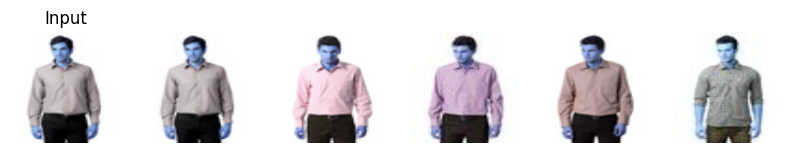

In [ ]:
#testing again after autoencoders
improved_recommend(20)

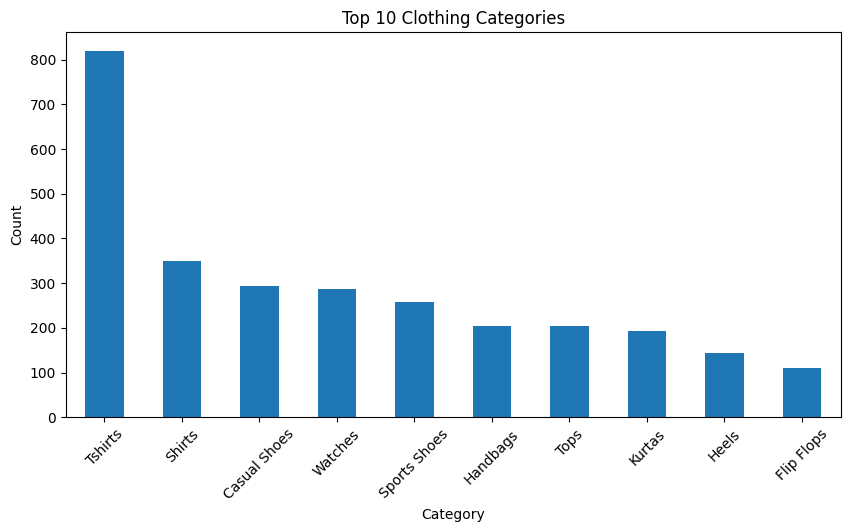

In [ ]:
#data distributoion
import matplotlib.pyplot as plt

top_categories = df['articleType'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind='bar')
plt.title("Top 10 Clothing Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

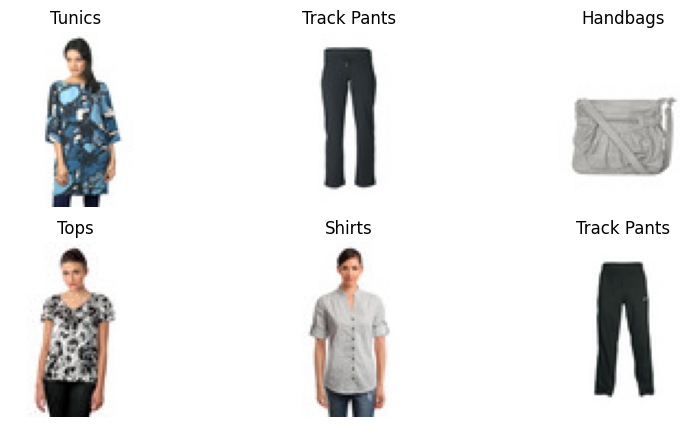

In [ ]:
#display sample images
plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    img = cv2.imread(df['image_path'][i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(df['articleType'][i])
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step


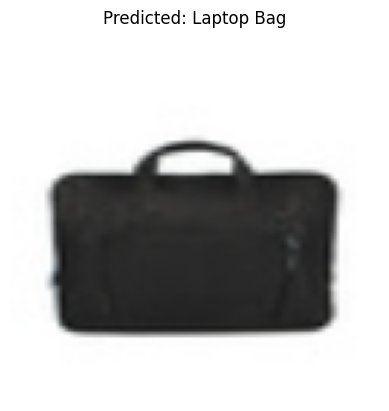

In [ ]:
#predicition
def predict_and_show(index):
    img = X_test[index]

    plt.imshow(img)
    plt.axis('off')

    pred = model.predict(img.reshape(1,128,128,3))
    label = list(label_map.keys())[np.argmax(pred)]

    plt.title(f"Predicted: {label}")
    plt.show()

predict_and_show(6)

In [ ]:
def avg_similarity(features, sample_size=200):
    sims = []
    for i in range(sample_size):
        sim = cosine_similarity([features[i]], features)[0]
        sims.append(np.mean(sim))
    return np.mean(sims)

# Before Autoencoder
before_score = avg_similarity(features)

# After Autoencoder
after_score = avg_similarity(encoded_features)

print("Average Similarity BEFORE AE:", before_score)
print("Average Similarity AFTER AE:", after_score)

Average Similarity BEFORE AE: 0.49759424
Average Similarity AFTER AE: 0.75736266


In [ ]:
print("1. CNN Features Only : Similarity Score:", before_score)
print("2. CNN + Autoencoder : Similarity Score:", after_score)

if after_score > before_score:
    print(" Autoencoder improved recommendation quality!")
else:
    print("No improvement observed")

1. CNN Features Only : Similarity Score: 0.49759424
2. CNN + Autoencoder : Similarity Score: 0.75736266
 Autoencoder improved recommendation quality!


In [ ]:
# COLOR FEATURE EXTRACTION

def extract_color(img):
    avg_color = np.mean(img, axis=(0,1))
    return avg_color

color_features = np.array([extract_color(img) for img in X])

In [ ]:
def hybrid_recommend(index, top_n=5):
    # Style similarity
    style_sim = cosine_similarity(
        [encoded_features[index]], encoded_features
    )[0]

    # Color similarity
    color_sim = cosine_similarity(
        [color_features[index]], color_features
    )[0]

    # Combine both
    final_sim = 0.7 * style_sim + 0.3 * color_sim

    similar_indices = final_sim.argsort()[-top_n-1:-1][::-1]

    # Display
    plt.figure(figsize=(10,4))
    plt.subplot(1,6,1)
    plt.imshow(X[index])
    plt.title("Input")
    plt.axis('off')

    for i, idx in enumerate(similar_indices):
        plt.subplot(1,6,i+2)
        plt.imshow(X[idx])
        plt.axis('off')

    plt.show()

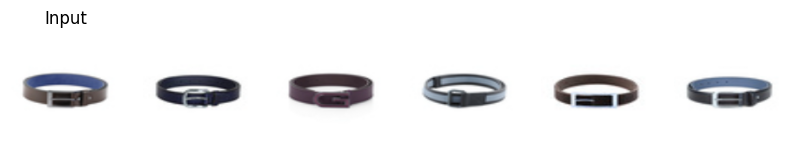

In [ ]:
hybrid_recommend(25)

In [ ]:
# TOP-K ACCURACY
def top_k_accuracy(k=5, sample_size=200):
    correct = 0

    for i in range(sample_size):
        sims = cosine_similarity([encoded_features[i]], encoded_features)[0]
        top_k = sims.argsort()[-k-1:-1]

        if y[i] in y[top_k]:
            correct += 1

    return correct / sample_size

print("Top-5 Accuracy:", top_k_accuracy(5))

Top-5 Accuracy: 0.885


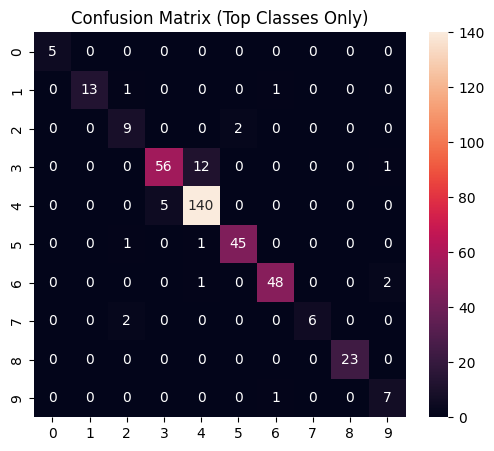

In [ ]:
import seaborn as sns

# only first 10 classes
labels_subset = list(range(10))

cm_small = confusion_matrix(y_true, y_pred_classes, labels=labels_subset)

plt.figure(figsize=(6,5))
sns.heatmap(cm_small, annot=True, fmt='d')
plt.title("Confusion Matrix (Top Classes Only)")
plt.show()

In [ ]:
print("\n FINAL EXPERIMENT RESULTS")
print(f"Similarity Before AE: {before_score:.4f}")
print(f"Similarity After AE: {after_score:.4f}")
print(f"Top-5 Accuracy: {top_k_accuracy(5):.4f}")

print("\nConclusion:")
if after_score > before_score:
    print("Autoencoder improved feature representation for outfit recommendation.")
else:
    print("Further tuning required.")


 FINAL EXPERIMENT RESULTS
Similarity Before AE: 0.4976
Similarity After AE: 0.7574
Top-5 Accuracy: 0.8850

Conclusion:
Autoencoder improved feature representation for outfit recommendation.
